<h1 align="center">
  Analysis of Inflation Trends in Egypt
   <img src="https://upload.wikimedia.org/wikipedia/commons/f/fe/Flag_of_Egypt.svg" width="40">
</h1>

Project Idea:
- Analyze inflation data (Inflation Rate, CPI, Avg Price Change)
- Study unemployment trends (Unemployment Rate)
- Link economic events to price changes such as:
    - Currency Devaluation / Float
    - CBR Interest Rate Hike
    - Economic Crises (e.g., COVID-19)
    - Policy Changes (e.g., fuel subsidy reduction)



Objectives:
- Understand how economic events affect inflation and sectoral prices
- Analyze the relationship between unemployment and inflation
- Provide actionable insights for economic decision-making

### Main Data Tables:

1️. dim_date (Date Dimension)
   - date_id (PK): Unique identifier for each date
   - full_date: Complete date (YYYY-MM-DD)
   - year: Year of the date
   - month: Month of the date

2️. dim_sector (Sector Dimension)
   - sector_id (PK): Unique identifier for each sector
   - sector_name: Name of the economic sector (e.g., Food, Transport, Eduction)
   - category: Category of the sector (optional grouping, e.g., Essential, Not Essential ,Services)

3️. dim_economic_indicator (Economic Indicators Dimension)
   - indicator_id (PK): Unique identifier for the indicator record
   - exchange_rate: Value of currency against USD (EGP/USD)
   - interest_rate: Central Bank interest rate (CBR rate)
   - fuel_price: Average fuel price (local currency)

4️. dim_event (Economic Events Dimension)
   - event_id (PK): Unique identifier for each event
   - event_type: Type of event (e.g., Float, Crisis, Interest, Policy)
   - event_name: Name/description of the event (e.g., "EGP Floatation 2016")
   - impact_level: Level of impact (High, Medium, Low)

5️.  fact_price_inflation (Fact Table)
   - fact_id (PK): Unique identifier for each record
   - date_id (FK): Linked to dim_date
   - sector_id (FK): Linked to dim_sector
   - indicator_id (FK): Linked to dim_economic_indicator
   - event_id (FK): Linked to dim_event (if any)
   - inflation_rate: Inflation rate (%) for the sector/date
   - CPI: Consumer Price Index value for the sector/date
   - avg_price: Average price of goods/services in the sector
   - price_change_pct: Percentage change in price compared to previous period

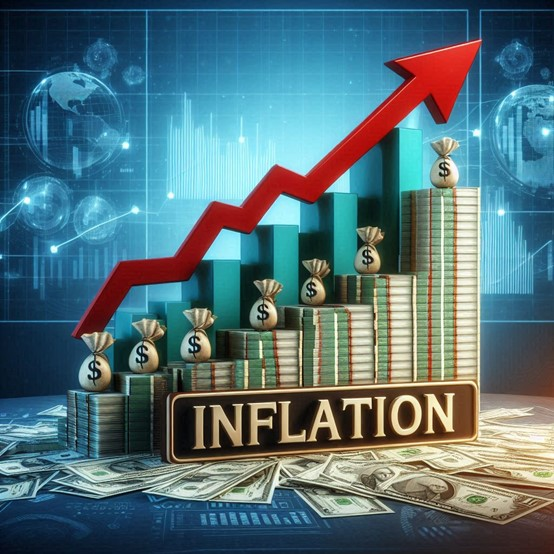

### 1. Import Libraries

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Merging
In this section, we load the **Fact Table** and its associated **Dimension Tables** (Date, Sector, Indicator, and Event). We perform a `left merge` to create a comprehensive master dataset (`egy_inf`) for analysis.

In [67]:
fact = pd.read_csv("/content/table 5.csv",sep=";")
dim_date = pd.read_csv("/content/table.csv",sep=";")
dim_sector = pd.read_csv("/content/table 4.csv",sep=";")
dim_indicator = pd.read_csv("/content/table 2.csv",sep=";")
dim_event = pd.read_csv("/content/table3.csv",sep=";")

In [68]:
egy_inf= fact.merge(dim_date, on='date_id', how='left') \
                .merge(dim_sector, on='sector_id', how='left') \
                .merge(dim_indicator, on='indicator_id', how='left') \
                .merge(dim_event, on='event_id', how='left')

In [69]:
egy_inf

,fact_id,date_id,sector_id,indicator_id,event_id,inflation_rate,cpi,avg_price,price_change_pct,full_date,...,month_name,sector_name,category,exchange_rate,interest_rate,fuel_price,unemployment_rate,event_type,event_name,impact_level
0,1,1,1,34,1,34.26,239.02,16.16,10.50,2016-01-01,...,January,Food & Beverages,Essential,17.88,12.06,6.87,9.22,Float,EGP Floatation 2016,High
1,2,1,2,97,3,14.48,173.32,29.63,13.11,2016-01-01,...,January,Housing & Utilities,Essential,54.67,23.55,6.68,7.22,Float,EGP Devaluation 2022,High
2,3,1,3,54,6,24.66,102.31,310.28,9.22,2016-01-01,...,January,Transportation,Services,17.19,20.12,6.87,6.74,Policy,Fuel Subsidy Reduction,High
3,4,1,4,82,0,12.89,252.45,145.88,6.22,2016-01-01,...,January,Healthcare,Services,27.30,8.49,6.75,9.30,NaN,NaN,NaN
4,5,1,5,94,6,33.95,120.53,178.66,9.30,2016-01-01,...,January,Education,Services,37.50,22.74,6.27,8.49,Policy,Fuel Subsidy Reduction,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,644,108,2,8,0,9.35,184.82,17.38,14.55,2024-12-01,...,December,Housing & Utilities,Essential,8.09,12.29,8.84,6.80,NaN,NaN,NaN
644,645,108,3,21,5,17.76,286.38,249.20,3.55,2024-12-01,...,December,Transportation,Services,16.06,25.24,8.39,7.65,Interest,CBR Interest Rate Hike,Medium
645,646,108,4,57,3,6.10,112.28,490.66,4.60,2024-12-01,...,December,Healthcare,Services,15.29,16.63,6.53,6.72,Float,EGP Devaluation 2022,High
646,647,108,5,101,0,26.94,263.10,159.40,13.52,2024-12-01,...,December,Education,Services,51.18,13.81,6.47,7.48,NaN,NaN,NaN


## 3. Exploratory Data Analysis (EDA)
Before cleaning, we perform an initial audit to understand the data's structure, identify data types, and check the statistical distribution of numerical variables.

In [70]:
egy_inf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fact_id            648 non-null    int64  
 1   date_id            648 non-null    int64  
 2   sector_id          648 non-null    int64  
 3   indicator_id       648 non-null    int64  
 4   event_id           648 non-null    int64  
 5   inflation_rate     648 non-null    float64
 6   cpi                648 non-null    float64
 7   avg_price          648 non-null    float64
 8   price_change_pct   648 non-null    float64
 9   full_date          648 non-null    object 
 10  year               648 non-null    int64  
 11  quarter            648 non-null    int64  
 12  month              648 non-null    int64  
 13  month_name         648 non-null    object 
 14  sector_name        648 non-null    object 
 15  category           648 non-null    object 
 16  exchange_rate      648 non

In [71]:
egy_inf.describe()

,fact_id,date_id,sector_id,indicator_id,event_id,inflation_rate,cpi,avg_price,price_change_pct,year,quarter,month,exchange_rate,interest_rate,fuel_price,unemployment_rate
count,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000
mean,324.500000,54.500000,3.500000,53.183642,3.067901,21.608549,194.640123,250.503056,7.933951,2020.000000,2.500000,6.500000,22.745077,17.571574,9.713765,8.024815
std,187.205769,31.199661,1.709144,31.514211,2.011179,8.867353,57.365121,145.536954,5.875365,2.583983,1.118898,3.454719,12.688254,5.453116,2.465939,1.125457
min,1.000000,1.000000,1.000000,1.000000,0.000000,6.090000,100.220000,6.330000,-2.990000,2016.000000,1.000000,1.000000,8.090000,8.430000,6.100000,6.000000
25%,162.750000,27.750000,2.000000,26.000000,1.000000,14.020000,143.795000,129.855000,2.960000,2018.000000,1.750000,3.750000,15.850000,12.282500,7.390000,7.150000
50%,324.500000,54.500000,3.500000,51.000000,3.000000,21.545000,192.305000,249.745000,8.125000,2020.000000,2.500000,6.500000,17.300000,18.100000,9.250000,7.990000
75%,486.250000,81.250000,5.000000,81.000000,5.000000,29.312500,246.665000,378.182500,12.752500,2022.000000,3.250000,9.250000,26.940000,22.740000,12.330000,8.980000
max,648.000000,108.000000,6.000000,108.000000,6.000000,37.970000,299.080000,499.870000,17.940000,2024.000000,4.000000,12.000000,54.670000,26.670000,13.890000,9.970000


## 4. Data Cleaning & Preprocessing
To ensure the integrity of our analysis, we check for duplicate records and missing values (NaNs). This step is crucial for maintaining data quality.

In [72]:
egy_inf.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
643,False
644,False
645,False
646,False


In [73]:
egy_inf.isna().sum()/len(egy_inf)*100

,0
fact_id,0.000000
date_id,0.000000
sector_id,0.000000
indicator_id,0.000000
event_id,0.000000
inflation_rate,0.000000
cpi,0.000000
avg_price,0.000000
price_change_pct,0.000000
full_date,0.000000


### Handling Missing Values
We identified missing values in the event-related columns. Instead of dropping these rows, we impute them with placeholder values (e.g., **'No Event'**, **'Unknown'**) to signify periods without specific economic shocks.

In [74]:
egy_inf[["event_name","event_type","impact_level"]] = (egy_inf[["event_name","event_type","impact_level"]].fillna({"event_name": "No Event","event_type":"Unknown",
"impact_level": "Low" }))

In [75]:
egy_inf[["event_name","event_type","impact_level"]]

,event_name,event_type,impact_level
0,EGP Floatation 2016,Float,High
1,EGP Devaluation 2022,Float,High
2,Fuel Subsidy Reduction,Policy,High
3,No Event,Unknown,Low
4,Fuel Subsidy Reduction,Policy,High
...,...,...,...
643,No Event,Unknown,Low
644,CBR Interest Rate Hike,Interest,Medium
645,EGP Devaluation 2022,Float,High
646,No Event,Unknown,Low


In [76]:
egy_inf.isna().sum()/len(egy_inf)*100

,0
fact_id,0.0
date_id,0.0
sector_id,0.0
indicator_id,0.0
event_id,0.0
inflation_rate,0.0
cpi,0.0
avg_price,0.0
price_change_pct,0.0
full_date,0.0


### Drop Unnecessary Columns
The relational ID columns (e.g., `fact_id`, `date_id`) are no longer required after the merge. We drop these redundant features to streamline the DataFrame for visualization.

In [77]:
egy_inf.drop(egy_inf[["fact_id","date_id","sector_id","indicator_id","event_id"]],axis=1,inplace=True)

In [78]:
egy_inf.head()

,inflation_rate,cpi,avg_price,price_change_pct,full_date,year,quarter,month,month_name,sector_name,category,exchange_rate,interest_rate,fuel_price,unemployment_rate,event_type,event_name,impact_level
0,34.26,239.02,16.16,10.50,2016-01-01,2016,1,1,January,Food & Beverages,Essential,17.88,12.06,6.87,9.22,Float,EGP Floatation 2016,High
1,14.48,173.32,29.63,13.11,2016-01-01,2016,1,1,January,Housing & Utilities,Essential,54.67,23.55,6.68,7.22,Float,EGP Devaluation 2022,High
2,24.66,102.31,310.28,9.22,2016-01-01,2016,1,1,January,Transportation,Services,17.19,20.12,6.87,6.74,Policy,Fuel Subsidy Reduction,High
3,12.89,252.45,145.88,6.22,2016-01-01,2016,1,1,January,Healthcare,Services,27.30,8.49,6.75,9.30,Unknown,No Event,Low
4,33.95,120.53,178.66,9.30,2016-01-01,2016,1,1,January,Education,Services,37.50,22.74,6.27,8.49,Policy,Fuel Subsidy Reduction,High


## 5. Data Analysis

In [79]:
inflation_trend = egy_inf.groupby("year")["inflation_rate"].mean().reset_index()
inflation_trend

,year,inflation_rate
0,2016,21.629028
1,2017,21.629583
2,2018,21.468056
3,2019,20.926250
4,2020,20.881111
5,2021,20.180833
6,2022,22.635139
7,2023,24.295000
8,2024,20.831944


In [81]:
price_trend_sector =egy_inf.groupby(["year", "sector_name"])["avg_price"].mean().reset_index()
price_trend_sector

,year,sector_name,avg_price
0,2016,Clothing,285.176667
1,2016,Education,204.715833
2,2016,Food & Beverages,163.038333
3,2016,Healthcare,253.115833
4,2016,Housing & Utilities,271.226667
5,2016,Transportation,303.430000
6,2017,Clothing,257.523333
7,2017,Education,193.107500
8,2017,Food & Beverages,297.150833
9,2017,Healthcare,247.485833


In [83]:
event_type_impact = egy_inf.groupby("event_type")["price_change_pct"].mean().reset_index()
event_type_impact

,event_type,price_change_pct
0,Crisis,8.880426
1,Float,7.915547
2,Interest,6.888667
3,Policy,8.109604
4,Unknown,7.848652


In [85]:
category_analysis = egy_inf.groupby("category")[["avg_price", "price_change_pct"]].mean().reset_index()
category_analysis

,category,avg_price,price_change_pct
0,Essential,242.550880,8.624630
1,Non-Essential,248.528704,8.520648
2,Services,256.462623,7.277932


In [88]:
sector_analysis = egy_inf.groupby("sector_name")[["inflation_rate", "avg_price"]
].mean().reset_index()
sector_analysis

,sector_name,inflation_rate,avg_price
0,Clothing,21.728148,248.528704
1,Education,22.657500,251.275741
2,Food & Beverages,21.375741,237.360093
3,Healthcare,20.467315,265.590648
4,Housing & Utilities,21.263519,247.741667
5,Transportation,22.159074,252.521481


In [91]:
corr = egy_inf[["inflation_rate","exchange_rate","fuel_price","interest_rate","avg_price"]].corr()
corr

,inflation_rate,exchange_rate,fuel_price,interest_rate,avg_price
inflation_rate,1.000000,0.087281,0.036278,0.078572,-0.054851
exchange_rate,0.087281,1.000000,-0.033734,0.081436,-0.044753
fuel_price,0.036278,-0.033734,1.000000,-0.029672,-0.005408
interest_rate,0.078572,0.081436,-0.029672,1.000000,0.000785
avg_price,-0.054851,-0.044753,-0.005408,0.000785,1.000000


# 6. Data Visualization

### Annual Inflation Trend Analysis Visualizing the fluctuation of inflation rates in Egypt from 2016 to 2024

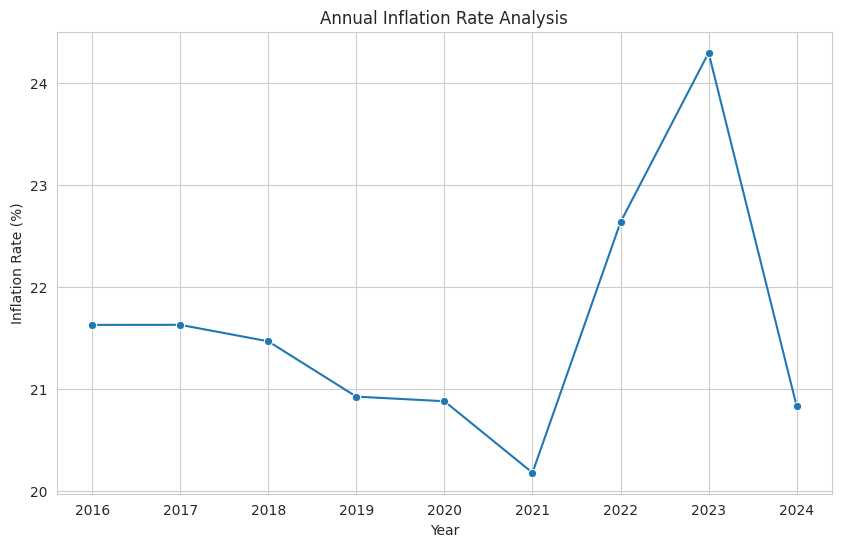

In [101]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=inflation_trend, x='year', y='inflation_rate', marker='o')
plt.title('Annual Inflation Rate Analysis')
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")
plt.grid(True)
plt.show()

###Sectoral Price Analysis Tracking how average prices evolved across different economic sectors

In [94]:
fig = px.line(price_trend_sector, x="year", y="avg_price", color="sector_name",
title="Price Trend by Sector Over Time",markers=True,
labels={"avg_price": "Average Price", "year": "Year", "sector_name": "Sector"})
fig.show()

###Event Impact on Prices Comparing average price change percentages based on economic event types.

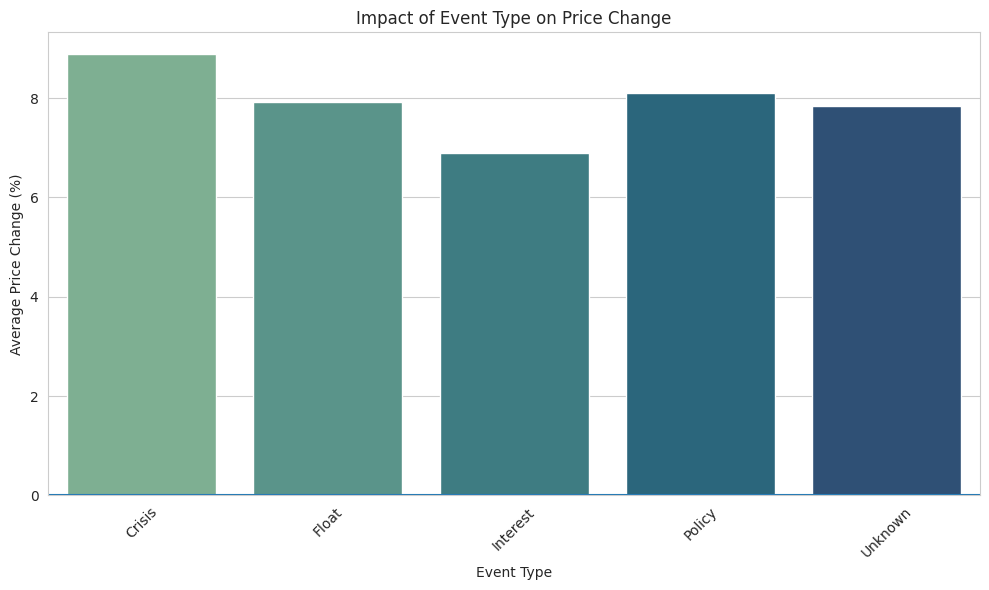

In [95]:
plt.figure(figsize=(10,6))
sns.barplot(data=event_type_impact,x="event_type",y="price_change_pct",palette="crest")
plt.axhline(0)
plt.xlabel("Event Type")
plt.ylabel("Average Price Change (%)")
plt.title("Impact of Event Type on Price Change")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Price Level by Category A look at the average price distribution across Essential, Non-Essential, and Services.

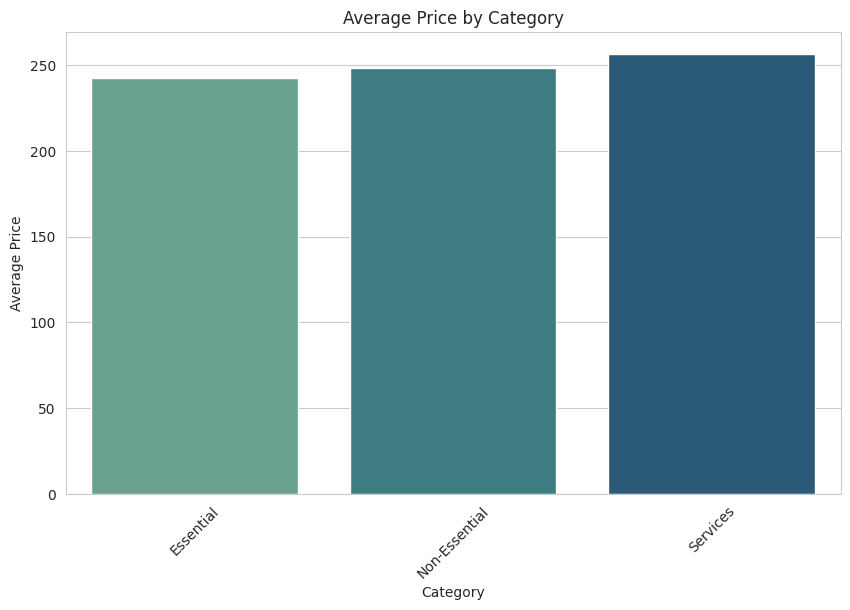

In [96]:
plt.figure(figsize=(10,6))
sns.barplot(data=category_analysis,x="category",y="avg_price",palette="crest")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.title("Average Price by Category")
plt.xticks(rotation=45)
plt.show()

###Price Change Percentage by Category Identifying which product categories are most sensitive to inflationary shocks

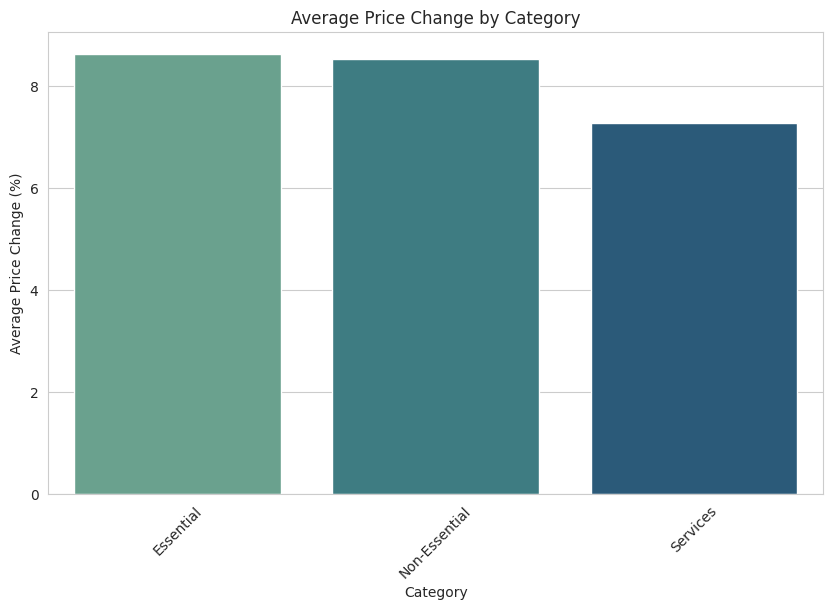

In [97]:
plt.figure(figsize=(10,6))
sns.barplot(data=category_analysis,x="category",y="price_change_pct",palette="crest")
plt.xlabel("Category")
plt.ylabel("Average Price Change (%)")
plt.title("Average Price Change by Category")
plt.xticks(rotation=45)
plt.show()

### Average Inflation Rate per Sector Determining which economic sectors experience the highest levels of persistent inflation.

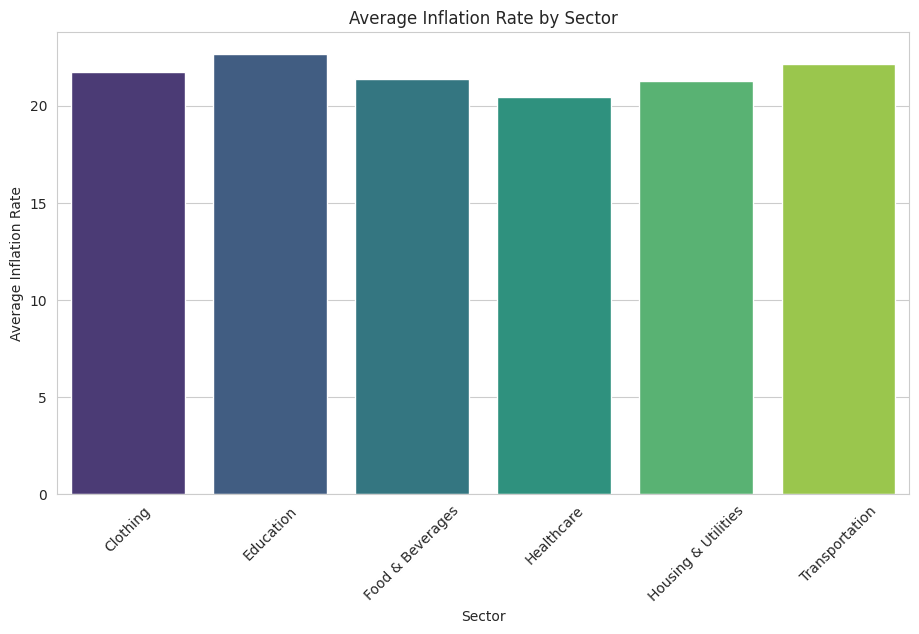

In [98]:
plt.figure(figsize=(11,6))
sns.barplot(data=sector_analysis,x="sector_name",y="inflation_rate",palette="viridis")
plt.xlabel("Sector")
plt.ylabel("Average Inflation Rate")
plt.title("Average Inflation Rate by Sector")
plt.xticks(rotation=45)
plt.show()

###  Average Price Levels per Sector Comparing the overall cost level across different sectors like Healthcare, Food, and Housing.

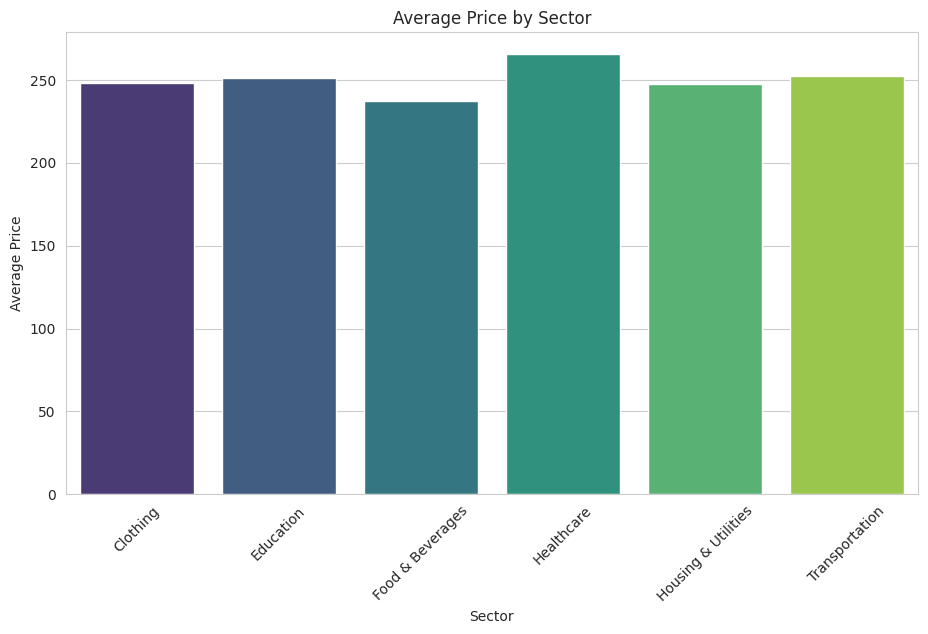

In [99]:
plt.figure(figsize=(11,6))
sns.barplot(data=sector_analysis,x="sector_name",y="avg_price",palette="viridis")
plt.xlabel("Sector")
plt.ylabel("Average Price")
plt.title("Average Price by Sector")
plt.xticks(rotation=45)
plt.show()


###Economic Indicators Correlation Matrix Analyzing the strength of the relationship between inflation, exchange rates, interest_rate,and fuel prices.

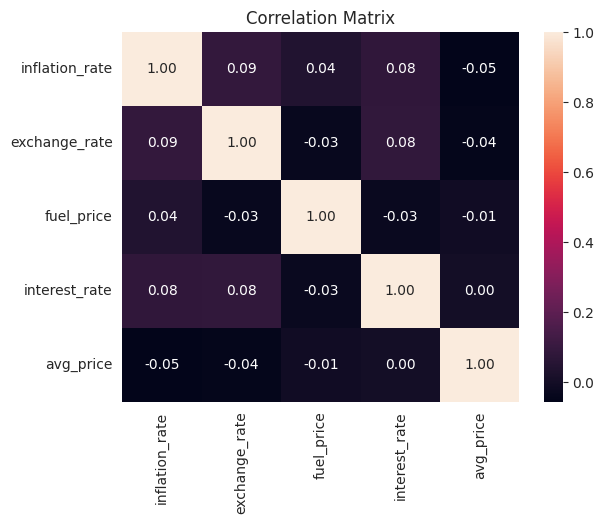

In [100]:
sns.heatmap(corr,annot=True,fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

##Summary of Findings:

1 - Inflation in Egypt shows persistent high levels with sharp increases following major economic shocks, particularly in **2016** and **2022**–**2023**.

2 - Price trends reveal that inflation does not affect all sectors equally; essential sectors such as food and transportation exhibit higher volatility and :faster responses to economic shocks.

3 - Crisis-type events lead to the highest average price changes, highlighting the vulnerability of prices to sudden economic shocks.

4 - Essential goods are the most sensitive to inflationary shocks, showing the highest average price changes despite having lower average prices than services.

5 - The data shows that sectors with the highest inflation are not necessarily the most expensive, highlighting different inflation dynamics across sectors.

6 - Correlation analysis shows weak linear relationships between inflation and key economic indicators.
